In [1]:
import iisignature
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

In [2]:
raw  = pd.read_csv('data/all_sessions_merged.csv')
meta = pd.read_csv('data/har_features.csv',
                   usecols=['session_id', 'sub_session_id',
                            'window_start_idx', 'is_walking', 'is_scrolling'])

CHANNELS = [
    'accelerometer_x', 'accelerometer_y', 'accelerometer_z',
    'gyroscope_x',     'gyroscope_y',     'gyroscope_z',
    'orientation_roll','orientation_pitch','orientation_yaw',
]
WINDOW_SIZE = 400
SIG_ORDER   = 3
N_CH        = len(CHANNELS)   # 9 sensor channels + 1 time channel = 10-dim path

print(f'Raw data : {len(raw):,} samples | {raw["session_id"].nunique()} sessions')
print(f'Windows  : {len(meta)}')
print(f'Log-sig dim (order {SIG_ORDER}, {N_CH+1}-dim path): '
      f'{iisignature.logsiglength(N_CH + 1, SIG_ORDER)}')

Raw data : 1,009,606 samples | 54 sessions
Windows  : 4966
Log-sig dim (order 3, 10-dim path): 385


## The signature transform

The **path signature** of a multivariate time series $X:[0,T]\to\mathbb{R}^n$
is the sequence of iterated integrals

$$S(X)_{i_1,\ldots,i_k} = \int_{0<t_1<\cdots<t_k<T} dX^{i_1}_{t_1}\cdots dX^{i_k}_{t_k}.$$

Its **log-signature** (the logarithm under the shuffle product) is the
non-redundant basis of the same information.  For an $n$-dimensional path,
the truncated log-signature at order $d$ captures:

| Order | Content |
|-------|---------|
| 1 | Total increment per channel |
| 2 | Signed areas swept by each pair of channels (encodes oscillation & correlation) |
| 3 | Higher-order path geometry (curvature, triple interactions) |

**As a kernel method**: the inner product $\langle\mathrm{LogSig}(X),\mathrm{LogSig}(Y)\rangle$
is a valid positive-definite kernel on path space — the *truncated signature kernel*.
Using a linear SVM on log-signature features is exactly equivalent to kernel SVM
with this kernel.

**Pre-processing**:
- **Basepoint normalisation**: subtract the window's starting value so the
  signature encodes dynamics, not absolute sensor offsets.
- **Time augmentation**: prepend $t\in[0,1]$ as an extra channel so the
  signature is sensitive to the speed at which the path is traversed.

In [3]:
JOINT_LABELS = ['sit_idle', 'sit_scroll', 'walk_idle', 'walk_scroll']
label_map    = {(0, 0): 'sit_idle', (0, 1): 'sit_scroll',
                (1, 0): 'walk_idle', (1, 1): 'walk_scroll'}

# Build per-session arrays; ffill→bfill→zero-fill handles absent sensor channels
sessions = {
    sid: grp[CHANNELS].reset_index(drop=True)
         .ffill().bfill().fillna(0).values.astype(np.float64)
    for sid, grp in raw.groupby('session_id')
}

prep = iisignature.prepare(N_CH + 1, SIG_ORDER)
t    = np.linspace(0, 1, WINDOW_SIZE).reshape(-1, 1)

X_sig, y_joint, groups = [], [], []

for _, row in meta.iterrows():
    w = sessions[row.session_id][row.window_start_idx:
                                  row.window_start_idx + WINDOW_SIZE]
    # Basepoint normalisation only: subtract the starting value so the path
    # starts at the origin, encoding dynamics rather than absolute sensor offsets.
    # We do NOT rescale per window — amplitude carries activity information
    # (e.g. walking has much larger accelerometer variance than sitting).
    # Global scaling is handled by StandardScaler inside the pipeline.
    path = np.concatenate([t, w - w[0]], axis=1)
    X_sig.append(iisignature.logsig(path, prep))
    y_joint.append(label_map[(row.is_walking, row.is_scrolling)])
    groups.append(row.sub_session_id)

X_sig   = np.array(X_sig,   dtype=np.float64)
y_joint = np.array(y_joint)
groups  = np.array(groups)

print(f'Feature matrix : {X_sig.shape}')
print(f'NaN values     : {np.isnan(X_sig).sum()}')
print(f'Inf values     : {np.isinf(X_sig).sum()}')

Feature matrix : (4966, 385)
NaN values     : 0
Inf values     : 0


## Classification

The log-signature at order 3 of a 10-dimensional (9 sensor + time) path
produces **385 features** per window.  Terms at different orders have very
different magnitudes (order-$k$ terms scale as path-length$^k$), so
StandardScaler is applied before the SVM.

We use an **RBF SVM**, which applies a Gaussian kernel on top of the
log-signature feature map.  This is equivalent to using a composition kernel
$K_{\text{sig+RBF}}(x, y) = \exp(-\gamma\,\|\mathrm{LogSig}(x)-\mathrm{LogSig}(y)\|^2)$,
a positive-definite kernel on path space.  A pure signature kernel would use
a linear SVM here; the RBF generalises to non-linear decision boundaries in
signature space, which helps when the relevant path features are not linearly
separable at this truncation order.

F1 macro: 0.459 ± 0.045  (5 folds)

              precision    recall  f1-score   support

    sit_idle       0.38      0.91      0.54      1075
  sit_scroll       0.47      0.08      0.14      1393
   walk_idle       0.64      0.55      0.59      1207
 walk_scroll       0.63      0.54      0.58      1291

    accuracy                           0.50      4966
   macro avg       0.53      0.52      0.46      4966
weighted avg       0.53      0.50      0.45      4966



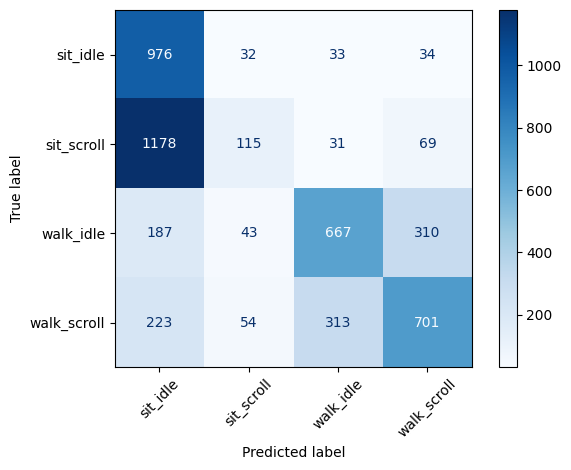

In [4]:
def evaluate(clf, X, y, groups, n_splits, labels):
    sgkf = StratifiedGroupKFold(n_splits=n_splits)
    y_true_all, y_pred_all, fold_f1s = [], [], []

    for train_idx, test_idx in sgkf.split(X, y, groups=groups):
        clf.fit(X[train_idx], y[train_idx])
        y_pred = clf.predict(X[test_idx])
        y_true_all.extend(y[test_idx])
        y_pred_all.extend(y_pred)
        fold_f1s.append(
            f1_score(y[test_idx], y_pred, average='macro', zero_division=0)
        )

    print(f'F1 macro: {np.mean(fold_f1s):.3f} ± {np.std(fold_f1s):.3f}  ({n_splits} folds)\n')
    print(classification_report(y_true_all, y_pred_all,
                                target_names=labels, zero_division=0))
    ConfusionMatrixDisplay(
        confusion_matrix(y_true_all, y_pred_all, labels=labels),
        display_labels=labels
    ).plot(cmap='Blues', xticks_rotation=45)
    plt.tight_layout()
    plt.show()


# RBF SVM: applies a Gaussian kernel on top of the log-signature features,
# effectively using a composition of the signature kernel and the RBF kernel.
# StandardScaler equalises magnitudes across signature orders (order-k terms
# scale as path-length^k and can differ by several orders of magnitude).
clf_sig = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVC(kernel='rbf', C=10, gamma='scale',
                  class_weight='balanced', random_state=42)),
])

evaluate(clf_sig, X_sig, y_joint, groups, n_splits=5, labels=JOINT_LABELS)